### Use "T4 GPU" and not CPU
  - model uses pytorch ,so its better to use google colab for preinstalled dependencies
  - use files.tar for example it has
    - ``0005890.png``
    - ``best.pt``
    - ``droplet_6.mp4``
  - ``best.pt`` is a pretrained weights for the droplet problem tou check the github for more information [like](https://github.com/panda-yoo/droplet-data/tree/master)
  - If you encounter a problem with ``files.tar``, try re-uploading and extracting it.

In [10]:
!tar -xvf /content/files.tar
!pip install ultralytics

0005890.png
best.pt
droplet_6.mp4


In [11]:
import numpy as np
from numpy.typing import NDArray
from ultralytics import YOLO
import pandas as pd


In [12]:
model = YOLO('/content/best.pt')


image 1/1 /content/0005890.png: 640x640 5 droplets, 37.1ms
Speed: 17.2ms preprocess, 37.1ms inference, 60.3ms postprocess per image at shape (1, 3, 640, 640)


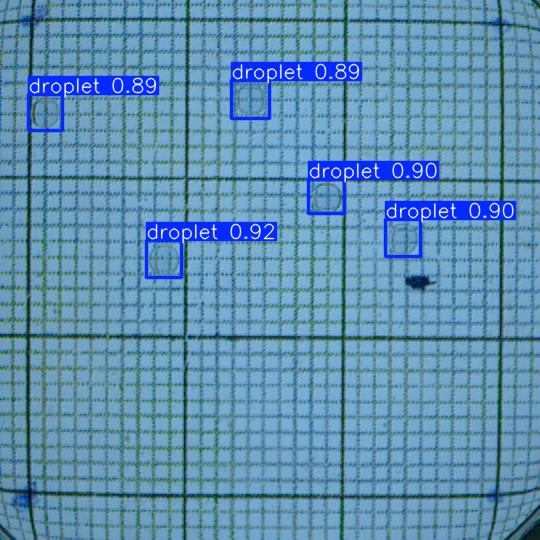

In [13]:
data = model.predict('./0005890.png')
for i in data:
  i.show()

In [14]:
# Run tracking on the video and save an annotated copy
PATH_VID = "/content/droplet_6.mp4"
track_results = model.track(
    source=PATH_VID,
    stream=False,
    show=False,
    save=True,
    project='output_droplet_tracking',
    name='droplet_run',
    exist_ok=True,
)

save_dir = track_results[0].save_dir if track_results else None
print(f'Annotated video saved to: {save_dir}')


requirements: Ultralytics requirement ['lap>=0.5.12'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 2 packages in 222ms
Prepared 1 package in 45ms
Installed 1 package in 6ms
 + lap==0.5.13

requirements: AutoUpdate success ✅ 0.8s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/849) /content/droplet_6.mp4: 640x640 6 droplets, 36.9ms
video 1/1 (frame 2/849) /c

In [15]:
data = []

for frame_idx, r in enumerate(track_results):
    boxes = r.boxes

    if boxes.id is not None:
        ids = boxes.id.cpu().numpy()
        xyxy = boxes.xyxy.cpu().numpy()

        for obj_id, box in zip(ids, xyxy):
            x1, y1, x2, y2 = box
            xc = (x1 + x2) / 2
            yc = (y1 + y2) / 2

            data.append([obj_id, frame_idx, xc, yc])
arr = np.array(data)

In [16]:
droplets = {}

for i in np.unique(arr[:, 0]):
    temp = arr[arr[:, 0] == i]

    # sort by time (VERY IMPORTANT)
    temp = temp[np.argsort(temp[:, 1])]

    droplets[int(i)] = temp[:, 2:]   # (x, y)

In [17]:

def cal_velocity(arr: NDArray, dt: float = 1.0) -> NDArray:

    x = arr[:, 0]
    y = arr[:, 1]

    v = np.zeros_like(arr)

    # central difference (interior points)
    v[1:-1, 0] = (x[2:] - x[:-2]) / (2 * dt)
    v[1:-1, 1] = (y[2:] - y[:-2]) / (2 * dt)

    # forward difference (first point)
    v[0, 0] = (x[1] - x[0]) / dt
    v[0, 1] = (y[1] - y[0]) / dt

    # backward difference (last point)
    v[-1, 0] = (x[-1] - x[-2]) / dt
    v[-1, 1] = (y[-1] - y[-2]) / dt

    return v

In [18]:

# Create initial DataFrame
df = pd.DataFrame(arr, columns=['droplet_id', 'frame_idx', 'x_coord', 'y_coord'])

# ---- Compute velocities ----
velocity_rows = []

for droplet_id, trajectory in droplets.items():
    velocities = cal_velocity(arr=trajectory)

    for frame_idx, (vx, vy) in enumerate(velocities):
        velocity_rows.append([droplet_id, frame_idx, vx, vy])

velocity_df = pd.DataFrame(
    velocity_rows,
    columns=['droplet_id', 'frame_idx', 'vx', 'vy']
)

# ---- Merge position and velocity ----
df = df.merge(velocity_df, on=['droplet_id', 'frame_idx'])

# ---- Reshape: one block per droplet ----
columns_needed = ['frame_idx', 'x_coord', 'y_coord', 'vx', 'vy']

df_reshaped = pd.concat(
    [
        df[df['droplet_id'] == d][columns_needed].reset_index(drop=True)
        for d in df['droplet_id'].unique()
    ],
    axis=1,
    keys=df['droplet_id'].unique()
)
df_reshaped.to_csv('output.csv')